In [103]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [104]:
N = 10
saturation = 16383
noise_rms = 20
dark = 150

sigma_x = 1
sigma_y = 2
theta = 30 * np.pi / 180

def gauss2D(x, y, x0, y0, sigma_x, sigma_y, A, theta=0):
    """Returns a 2D Gaussian function evaluated at (x, y) with center (x0, y0), standard deviations sigma_x and sigma_y, and amplitude A."""
    return A * np.exp(-(((x - x0) * np.cos(theta) + (y - y0) * np.sin(theta))**2 / (2 * sigma_x**2) + ((-(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta))**2 / (2 * sigma_y**2))))

def flux_to_amp(flux, sigma_x, sigma_y):
    """Converts a total flux to an amplitude for a 2D Gaussian with given standard deviations."""
    return flux / (2 * np.pi * sigma_x * sigma_y)

def output(flux):
    img = dark + np.random.normal(0, noise_rms, (N, N)) + gauss2D(*np.meshgrid(np.arange(N), np.arange(N)), N//2, N//2, sigma_x, sigma_y, flux_to_amp(flux, sigma_x, sigma_y), theta)
    img = np.clip(img, 0, saturation)
    return img - dark

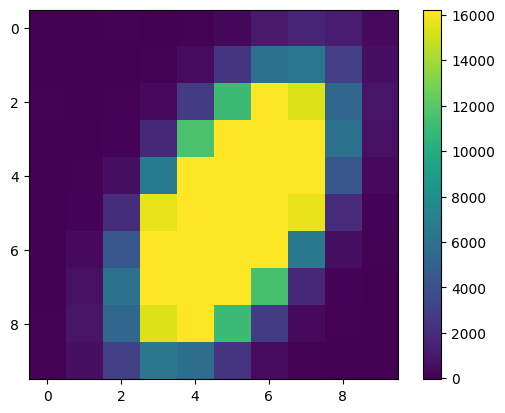

In [105]:
im = plt.imshow(output(1000000))
plt.colorbar(im)
plt.show()

In [106]:
f"{np.sum(output(0)) / np.sum(output(1000000)):.2e}"

'-1.31e-04'

In [107]:
def model(flux, x0, y0, sigma_x, sigma_y, theta=0):
    img = dark + gauss2D(*np.meshgrid(np.arange(N), np.arange(N)), N//2, N//2, sigma_x, sigma_y, flux_to_amp(flux, sigma_x, sigma_y), theta)
    img = np.clip(img, 0, saturation)
    return img - dark

In [111]:
# Fit model

data = output(1000000)
popt, pcov = curve_fit(lambda f, flux, x0, y0, sigma_x, sigma_y, theta: model(flux, x0, y0, sigma_x, sigma_y, theta).flatten(), np.zeros(data.size), data.flatten(), p0=[1000000, N//2, N//2, sigma_x, sigma_y, 0], bounds=(0, 1e7))
popt[0]

np.float64(999871.3117561815)

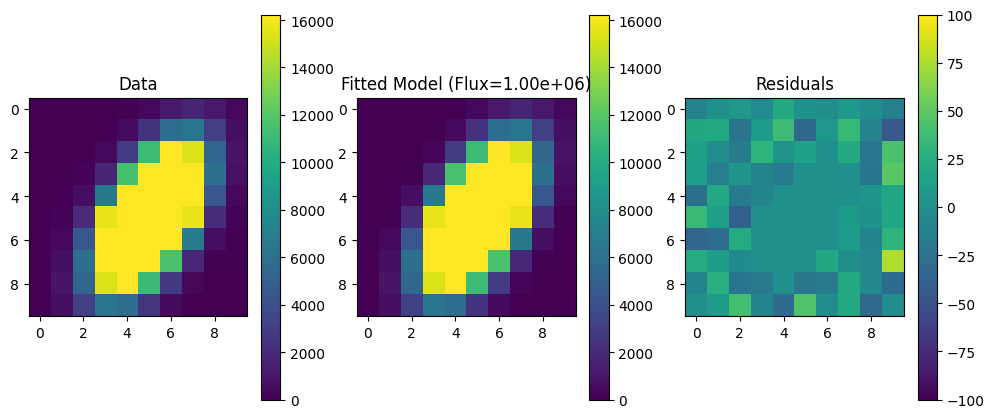

In [112]:
# Plot fit

fitted_flux = popt[0]
fitted_img = model(*popt)
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title("Data")
plt.imshow(data, vmin=0, vmax=saturation - dark)
plt.colorbar()
plt.subplot(1, 3, 2)
plt.title(f"Fitted Model (Flux={fitted_flux:.2e})")
plt.imshow(fitted_img, vmin=0, vmax=saturation - dark)
plt.colorbar()
plt.subplot(1, 3, 3)
plt.title("Residuals")
plt.imshow(data - fitted_img, vmin=-100, vmax=100)
plt.colorbar()
plt.show()
